In [1]:
import queer
from queer.utils import path_create
from queer.mesh import mesh_crystal,mesh_cartesian,angstrom2reciprocal,reciprocal2angstrom
import numpy as np
from queer.arpes import arpes_mesh,arpes_mesh_plot,binding_k, arpes_equation, arpes_path
from queer.response import spectral_from_eig,spectral_from_green
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import time
import os
from queer.functions import get_rotation_matrix

In [2]:
# Input files
file_path = "./NiTe2/"
hr = "wannier90_hr.dat"
model = queer.model(path=file_path,ef=7.5932,poscar='POSCAR')
g_vec = model.g_vec

In [3]:
k_points = 300
custom_points = [
    [1/2, 0, 0],   # M
    [0, 0, 0],     # Gamma
    [1/2, 0, 0],   # M
    [1/3, 1/3, 0], # K
    [0, 0, 0],      # Back to Gamma
    [1/3, 1/3, 0] # K
]

# Create the path
corner_points, path = path_create(k_points, custom_points)

# Define symmetry points and labels
sym = corner_points
labels = ['M','Γ', 'M', 'K', 'Γ', 'K']

Calculating band structure...
Plotting band structure...


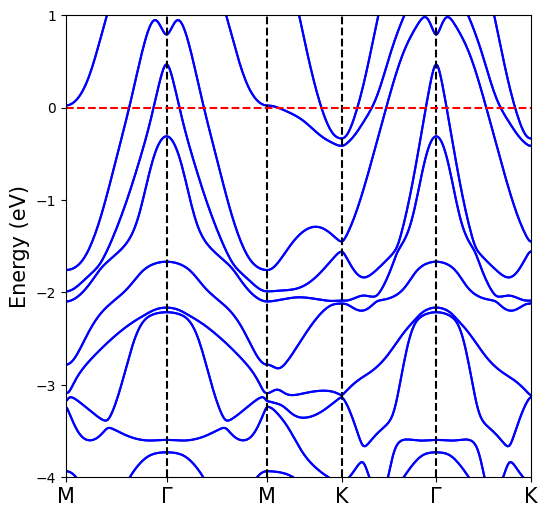

In [4]:
# Calculate band dispersion along the path
print("Calculating band structure...")  
bands = model.calculate_energy(path)

# Plot bands
print("Plotting band structure...")
model.plot_electron_path(bands, sym, labels, ylim=[-4,1])

In [16]:
N = 300
factor = 4

In [17]:
k_cartesian = mesh_cartesian(N=[N,N,1],factor=factor,center=True)

In [18]:
k_crystal = angstrom2reciprocal(k_cartesian,g_vec=model.g_vec)

In [19]:
band = model.calculate_energy(k_crystal) 

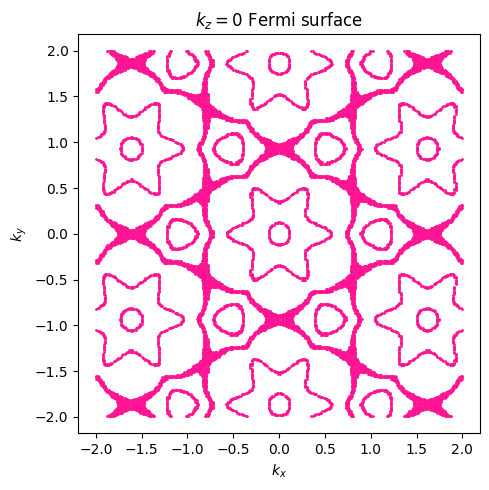

In [105]:
delta = 0.04  # eV
nband, nk = band.shape
kx, ky, kz = k_cartesian.T  # each (nk,)

# Points where at least one band is near zero
near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)

plt.figure(figsize=(5, 5))
plt.scatter(kx[near_any], ky[near_any], s=1, c='deeppink')
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(fr"$k_z=0$ Fermi surface")
plt.axis("equal")
plt.tight_layout()
plt.savefig(f'{file_path}kz_0.png',dpi=300,bbox_inches='tight')
plt.show()


In [106]:
N = 300
factor = 4
k_cartesian = mesh_cartesian(N=[N,N,1],factor=factor,center=True)
nk = N      
n_kz = 10
half_kz = np.linalg.norm(model.g_vec[-1]) / 2
kz_vals = np.linspace(0.0, half_kz, n_kz)
k_cartesian_z = np.repeat(k_cartesian[None, :, :], n_kz, axis=0)
k_cartesian_z[:, :, 2] = kz_vals[:, None]



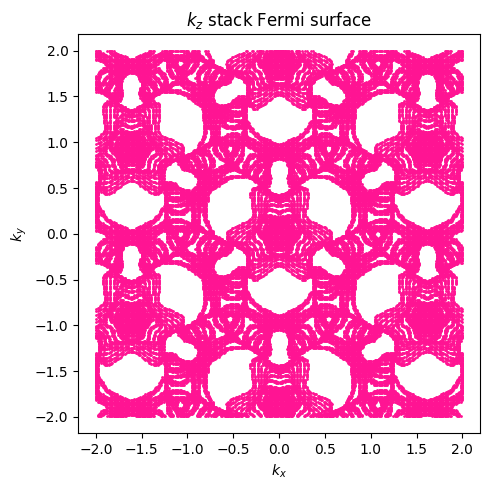

In [111]:
plt.figure(figsize=(5, 5))
energies = []
for z_slice in k_cartesian_z:
    k_crystal_slice = angstrom2reciprocal(z_slice, model.g_vec)
    band = model.calculate_energy(k_crystal_slice)
    energies.append(band)


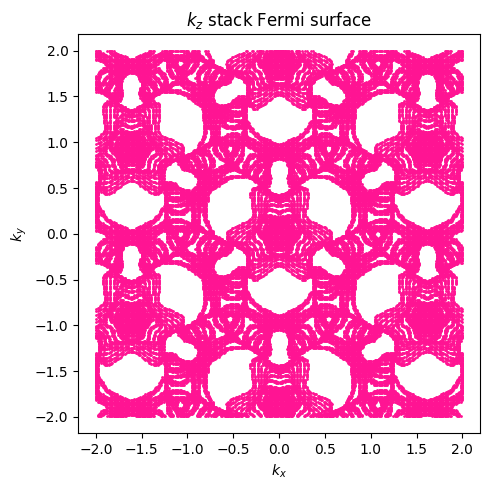

In [112]:
plt.figure(figsize=(5, 5))
delta = 0.04  # eV
for band in energies:
    nband, nk = band.shape
    near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)
    plt.scatter(z_slice.T[0][near_any], z_slice.T[1][near_any], s=1,c='deeppink')
plt.xlabel(r"$k_x$")
plt.ylabel(r"$k_y$")
plt.title(fr"$k_z$ stack Fermi surface")
plt.axis("equal")
plt.tight_layout()
plt.savefig(f'{file_path}kz_stack.png',dpi=300,bbox_inches='tight')
plt.show()

In [68]:
N = 300
factor = 4
binding_range = [0, 0.05]
binding_step = 0.1
photon_energy = 21.2
fermi_energy = 0
V0 = 20
binding_energy=0


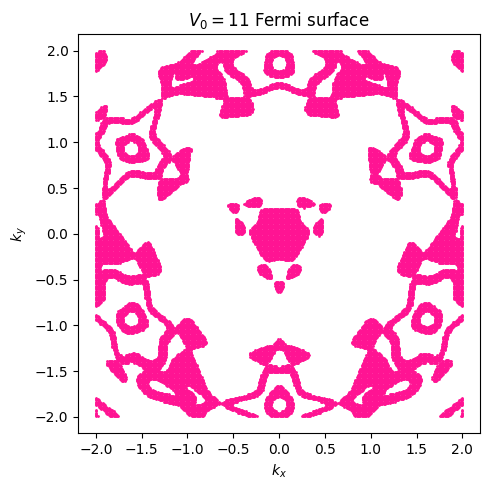

In [81]:
delta = 0.2  # eV
for V0 in [11]:
    k_cartesian_curve = arpes_mesh(photon_energy,fermi_energy,binding_energy,V0,N,factor)
    k_crystal_curve = angstrom2reciprocal(k_cartesian_curve.T, model.g_vec)
    band = model.calculate_energy(k_crystal_curve)
    nband, nk = band.shape
    near_any = np.any(np.abs(band) <= delta, axis=0)  # (nk,)
    plt.figure(figsize=(5, 5))
    plt.scatter(k_cartesian_curve[0][near_any], k_cartesian_curve[1][near_any], s=1,c='deeppink')
    plt.xlabel(r"$k_x$")
    plt.ylabel(r"$k_y$")
    plt.title(fr"$V_0={V0}$ Fermi surface")
    plt.axis("equal")
    plt.tight_layout()
    plt.savefig(f'{file_path}v0_{V0}.png',dpi=300,bbox_inches='tight')
    plt.show()

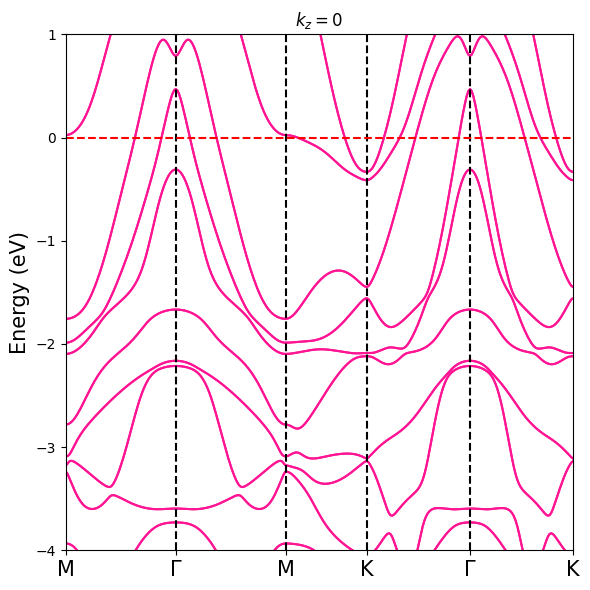

In [ ]:
n_kz = 10
half_kz = 1 / 2
kz_vals = np.linspace(0.0, half_kz, n_kz)
path_crystal_z = np.repeat(path[None, :, :], n_kz, axis=0)
path_crystal_z[:, :, 2] = kz_vals[:, None]



plt.figure(figsize=(6, 6))
for path_z in path_crystal_z:
    band = model.calculate_energy(path_z)
    for i in band:
        plt.plot(i, c="deeppink",)
plt.ylabel("Energy (eV)", fontsize=15)
plt.xticks(ticks=sym, labels=labels, fontsize=15)
plt.xlim(sym[0], sym[-1])
plt.ylim(-4,1)
for i in sym[1:-1]:
    plt.axvline(i, c="black", linestyle="--")
plt.axhline(0, linestyle="--", color="red")
plt.title(fr"$k_z$ stack")
# plt.axis("equal")
plt.tight_layout()
plt.savefig(f'{file_path}path.png',dpi=300,bbox_inches='tight')
plt.show()


In [5]:
g_vec = model.g_vec

In [ ]:
photon_energy = 21.2
fermi_energy = 0
# binding_range = [0, 0.05]
# binding_step = 0.1
# binding_energy=0
v0_array = [15,16,17,18,19]
binding_array=np.linspace(0,-3,100)
v0_dict ={}``
for V0 in v0_array:
    spectral_dict = {}
    for binding_energy in binding_array:
        spectral_dict[binding_energy] = []
        curved_path = arpes_path(path,g_vec,photon_energy,-binding_energy,fermi_energy,V0)
        bands = model.calculate_energy(curved_path) +0.5
        for i,eig in enumerate(bands.T):
            spectral_dict[binding_energy].append(spectral_from_eig(eig,omega_list=[binding_energy],eta=0.3))
    v0_dict[V0] = spectral_dict


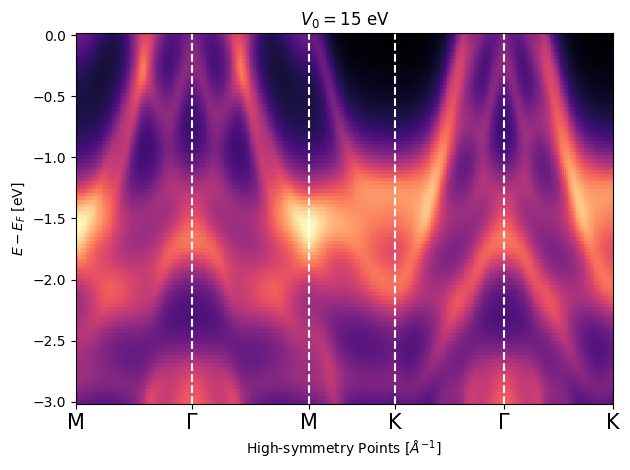

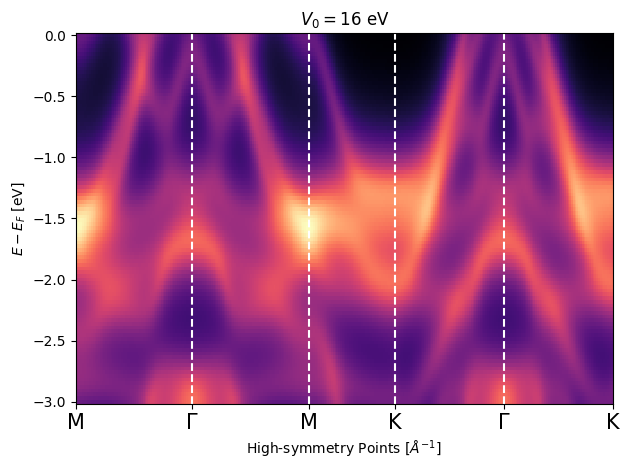

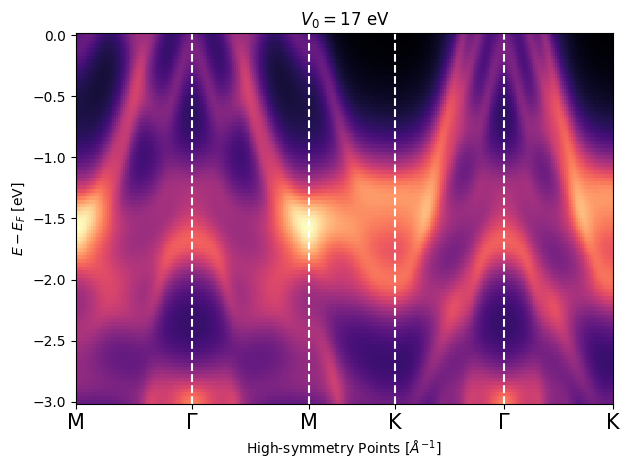

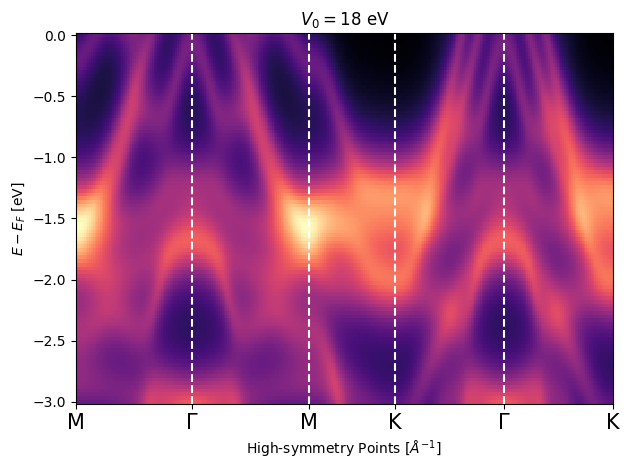

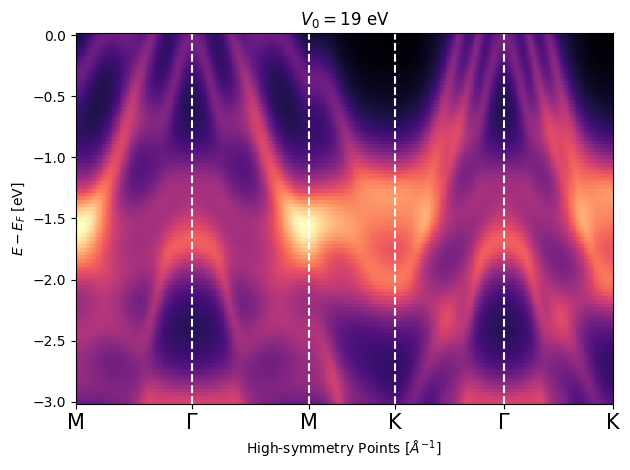

In [87]:
for j,spectral_dict in v0_dict.items():
    y = np.array(sorted(spectral_dict.keys()))
    
    # Stack and flatten each (Nk,1) array into shape (Nk,)
    A = np.vstack([np.array(spectral_dict[val]).flatten() for val in y])
    
    # Define x-axis (use your actual k-values if available)
    x = np.arange(A.shape[1])
    plt.pcolormesh(x, y, A, shading='auto',cmap='magma')
    for i in sym[1:-1]:
        plt.axvline(i, c="white", linestyle="--")
    # plt.axhline(0, linestyle="--", color="red")
    plt.xticks(ticks=sym, labels=labels, fontsize=15)
    plt.xlim(sym[0], sym[-1])
    plt.ylabel('$E - E_F$ [eV]')
    plt.title(rf"$V_0 = {j}$ eV")
    plt.xlabel(r"High-symmetry Points [$\AA^{-1}$] ")
    plt.tight_layout()
    plt.savefig(f'{file_path}path_V0_{j}.png',
            dpi=300,
            bbox_inches='tight')
    plt.show()


In [66]:
photon_energy = 21.2
fermi_energy = 0
v0_array = [10,15,20]
binding_array=np.linspace(0,3,50)
v0_dict ={}
delta= 0.04
for V0 in v0_array:
    spectral_dict = {}
    for binding_energy in binding_array:
        spectral_dict[binding_energy] = []
        curved_path = arpes_path(path,g_vec,photon_energy,binding_energy,fermi_energy,V0)
        bands = model.calculate_energy(curved_path)
        for i,eig in enumerate(bands.T):
            near_any = np.any(np.abs(eig + binding_energy) <= delta, axis=0)  # (nk,)
            spectral_dict[binding_energy].append(near_any)
    v0_dict[V0] = spectral_dict


In [67]:
v0_dict

{10: {np.float64(0.0): [np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.True_,
   np.True_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
   np.False_,
 

In [ ]:
photon_energy = 21.2
fermi_energy = 0
# binding_range = [0, 0.05]
# binding_step = 0.1
# binding_energy=0
v0_array = [10,15,20]
binding_array=np.linspace(0,-3,50)
v0_dict ={}
for V0 in v0_array:
    spectral_dict = {}
    for binding_energy in binding_array:
        spectral_dict[binding_energy] = []
        curved_path = arpes_path(path,g_vec,photon_energy,-binding_energy,fermi_energy,V0)
        bands = model.calculate_energy(curved_path)
        for i,eig in enumerate(bands.T):
            mask = np.abs(eig - binding_energy) <= delta   # shape (n_bands, n_k)
            bands_in_window = eig[mask]  # 1D array of all ε_{n,k} close to binding_energy

            spectral_dict[binding_energy].append(spectral_from_eig(eig,omega_list=[binding_energy],eta=0.1))
    v0_dict[V0] = spectral_dict

KeyboardInterrupt: 

/tmp/ipykernel_3406003/287975571.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("viridis")


ValueError: Unable to determine Axes to steal space for Colorbar. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.

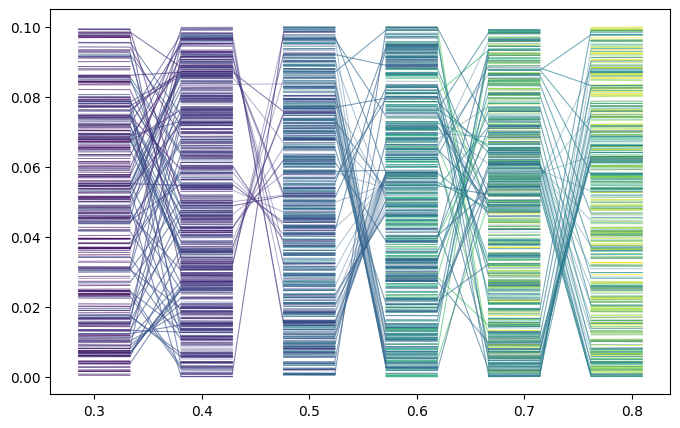